In [2]:
# Load data form scratch

from transcription_pipeline import preprocessing_pipeline
from tqdm import tqdm

# IMPORTANT: File path has to be relative to Jupyter Notebook.
dataset_list = [
    "Data/2025-04-14-Nick/MCP-mSG_His-RFP_Var2(001)_embryo28"
]

for dataset_name in tqdm(dataset_list):
    # Imports dataset into memory, trimming the last frame of each time-series as requested
    dataset = preprocessing_pipeline.DataImport(
        name_folder=dataset_name,
        # trim_series=True,
        # registration_channel=1,
        working_storage_mode="zarr",
        zarr_chunk_memory_size="512 MB",
        # import_previous=True,
    )

    # Saves each channel of the dataset as a zarr, and pickles together dictionaries
    # of relevant metadata
    dataset.save()

  0%|          | 0/1 [00:00<?, ?it/s]

uint16
(17, 21, 256, 1024)


100%|██████████| 1/1 [03:21<00:00, 201.12s/it]


In [9]:
# Load data from zarr

from transcription_pipeline import preprocessing_pipeline
from tqdm import tqdm

# IMPORTANT: File path has to be relative to Jupyter Notebook.
dataset_path = "Data/2025-04-14-Nick/MCP-mSG_His-RFP_Var2(001)_embryo28"

dataset = preprocessing_pipeline.DataImport(
    name_folder=dataset_path,
    # trim_series=True,
    # registration_channel=1,
    # working_storage_mode="zarr",
    # zarr_chunk_memory_size="1 GB",
    import_previous=True,
)

In [3]:
# Start Dask client for parallelization
from dask.distributed import LocalCluster, Client

cluster = LocalCluster(
    host="localhost",
    # scheduler_port=8786,
    threads_per_worker=1,
    n_workers=14,
    memory_limit="20GB",
)

client = Client(cluster)

/home/enzecheng/miniforge3/envs/transcription_pipeline/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42197 instead
  warnings.warn(


In [4]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:42197/status,
Dashboard: http://127.0.0.1:42197/status,Workers: 14
Total threads: 14,Total memory: 260.77 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35803,Workers: 14
Dashboard: http://127.0.0.1:42197/status,Total threads: 14
Started: Just now,Total memory: 260.77 GiB
Comm: tcp://127.0.0.1:44189,Total threads: 1
Dashboard: http://127.0.0.1:44025/status,Memory: 18.63 GiB
Nanny: tcp://127.0.0.1:45105,


In [5]:
client.dashboard_link

'http://127.0.0.1:42197/status'

In [6]:
# Run spot segmentation, filtering and quantification and transfer nuclear labels
# over to corresponding spots.
from transcription_pipeline import spot_pipeline

In [7]:
# Need to add a memory sink for label expansion, otherwise nuclear labels
# get pulled into memory whole

In [10]:


spot_tracking = spot_pipeline.Spot(
    data=dataset.channels_full_dataset[0],
    global_metadata=dataset.export_global_metadata[0],
    frame_metadata=dataset.export_frame_metadata[0],
    search_range_um=1.5,    # how far you expect the spots move between frames
    retrack_search_range_um=3,
    memory=3,
    min_track_length=1,
    series_splits=dataset.series_splits,
    series_shifts=dataset.series_shifts,
    keep_bandpass=False,
    keep_futures=False,
    keep_spot_labels=False,
    evaluate=False,
    client=client,
    threshold_factor=1.4,   # balance between background and real signal (triangle threshold) may play with this value
)

spot_tracking.extract_spot_traces(
    working_memory_mode="zarr",
    working_memory_folder=dataset_path,
)


# Saves tracked spot mask as a zarr, and pickles dataframes with spot fitting and
# quantification information.
spot_tracking.save_results(
    name_folder=dataset_path, save_array_as=None
)

/mnt/Data1/Enze/transcription_pipeline/transcription_pipeline/spot_pipeline.py:734: UserWarning: `working_memory_mode` set to 'zarr', will not pull `spot_labels` into memory.
  warnings.warn(
2025-04-28 16:10:04,113 - distributed.worker - WARNING - Compute Failed
Key:       segmentation_df_func-8b6490b649e0b5ad938dbcbfc5b0fddd
Function:  segmentation_df_func
args:      (array([[[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
   

ValueError: cannot convert float NaN to integer

In [20]:
dataset.channels_full_dataset[0].chunks

(45, 21, 1024, 1024)

In [23]:
263/45

5.844444444444444

In [21]:
dataset.channels_full_dataset[0].shape

(263, 21, 1024, 1024)

In [14]:
dataset.channels_full_dataset[0].nbytes/6/1e9

1.930428416

In [7]:
# Load existing spot segmentation with different parameter set

%%time

spot_tracking = spot_pipeline.Spot(
    data=dataset.channels_full_dataset[2],
    global_metadata=dataset.export_global_metadata[2],
    frame_metadata=dataset.export_frame_metadata[2],
    labels=nuclear_tracking.reordered_labels,
    max_num_spots=2,
    expand_distance=3,
    search_range_um=1.5,
    retrack_search_range_um=3,
    memory=3,
    min_track_length=1,
    series_splits=dataset.series_splits,
    series_shifts=dataset.series_shifts,
    keep_bandpass=False,
    keep_futures=False,
    keep_spot_labels=False,
    evaluate=False,
    client=client,
)

spot_tracking.read_results(
    name_folder="embryo2",
    import_all=True,
)

/mnt/Data1/Chance/Transcription Pipeline/transcription_pipeline/transcription_pipeline/spot_pipeline.py:206: UserWarning: Resolution is anisotropic in X and Y, segmentation parameters should be handled manually.
  warnings.warn(


CPU times: user 116 ms, sys: 19.4 ms, total: 135 ms
Wall time: 204 ms


In [25]:
spot_tracking.spot_dataframe

,label,z,y,x,frame,t_s,t_frame,raw_spot,coordinates_start,covariance_matrix,...,cost,norm_cost,intensity_from_fit,intensity_std_error_from_fit,intensity_from_neighborhood,intensity_std_error_from_neighborhood,background_intensity_from_neighborhood,background_intensity_std_error_from_neighborhood,nuclear_label,particle
0,3,0.860215,1.349462,384.994624,0,0.000000,0,None,"[0, -2, -3, 380]",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,5,0.263158,2.000000,410.000000,0,0.000000,0,None,"[0, -2, -2, 406]",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,6,0.000000,7.108108,410.648649,0,0.000000,0,None,"[0, -2, 3, 406]",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,14,0.200000,18.400000,198.750000,0,0.000000,0,None,"[0, -2, 14, 194]",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,18,0.407407,24.185185,422.592593,0,0.000000,0,None,"[0, -2, 20, 418]",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13728,49,6.170067,221.435272,290.933702,485,1863.320000,492,"[[[1, 0, 1, 2, 0, 2, 0, 3, 1], [1, 1, 1, 1, 1,...","[5, 4, 217, 285]","[[3408.900554625531, 0.017010740626666226, -0....",...,293.774718,0.002568,26.855583,8319.137417,79.448903,33.559483,1.145548,0.113840,0,0
13729,53,8.123559,154.714938,326.882616,485,1863.660000,492,"[[[0, 2, 2, 3, 5, 1, 0, 2, 0], [1, 2, 1, 2, 0,...","[5, 5, 150, 322]","[[0.06015757012343001, 3.6038686703276226e-07,...",...,285.472669,0.020201,73.425537,20.784878,-1.616699,35.583844,1.367451,0.116394,0,0
13730,56,7.600000,255.000000,176.550000,485,1863.660000,492,None,"[5, 5, 251, 172]",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
13731,57,8.678068,24.174733,340.325801,485,1864.014999,492,"[[[1, 2, 1, 0, 0, 0, 0, 0, 2], [0, 2, 2, 2, 1,...","[5, 6, 19, 335]","[[0.013433755068661566, -5.321839625627961e-06...",...,304.543507,0.008228,49.058062,9.090611,84.589088,31.561741,1.270402,0.096016,57,9


In [32]:
from transcription_pipeline.spot_analysis import compile_data
filtered_dataframe = spot_tracking.spot_dataframe[
    spot_tracking.spot_dataframe["particle"] != 0
].copy()
filtered_compiled_data = compile_data.compile_traces(
    filtered_dataframe,
    compile_columns_spot=[
        "frame",
        "t_s",
        "intensity_from_neighborhood",
        "intensity_std_error_from_neighborhood",
        "background_intensity_from_neighborhood",
    ],
    # nuclear_tracking_dataframe=nuclear_tracking.mitosis_dataframe,
    # compile_columns_nuclear=[
    #     "nuc_t_s",
    #     "nuclear_intensity_mean",
    #     "nuclear_intensity_stdev",
    #     "nuclear_cycle"
    # ],
    ignore_negative_spots=True,
)

In [33]:
filtered_compiled_data

,particle,frame,t_s,intensity_from_neighborhood,intensity_std_error_from_neighborhood,background_intensity_from_neighborhood
0,1,"[463, 468, 472, 473, 477, 479, 480, 482, 485]","[1778.6800003051758, 1797.954999923706, 1812.7...","[111.55643243243243, 86.31883653846154, 24.092...","[30.528776535622114, 33.42650701024522, 39.389...","[1.1768918918918918, 1.1379519230769233, 1.342..."
1,2,[485],[1861.9599990844727],[31.128178571428574],[32.80885121022518],[1.3431071428571426]
2,3,"[386, 387, 388, 390, 391, 392, 393, 394, 396, ...","[1488.6000003814697, 1492.3880004882812, 1496....","[89.39234545454546, 24.367817307692306, 78.325...","[37.20335218948968, 38.66980636463045, 35.9401...","[1.4990181818181818, 1.706682692307692, 1.6165..."
3,4,"[437, 439, 443, 450, 452, 453, 455, 456, 458, ...","[1681.2999992370605, 1688.5200004577637, 1704....","[67.63395283018868, 64.13552293577982, 76.3116...","[30.089570210283313, 31.221063652432793, 34.69...","[1.1643867924528304, 1.2540917431192662, 1.321..."
4,5,"[455, 456, 458, 464, 465, 466, 468, 470, 472, ...","[1748.7399997711182, 1752.5279998779297, 1760....","[15.925076923076924, 62.06902542372882, 72.615...","[40.54382936465543, 30.951190378793754, 37.726...","[1.4709615384615387, 1.1709915254237286, 1.199..."
...,...,...,...,...,...,...
366,387,[17],[66.04300117492676],[27.00209090909091],[44.27195374263578],[1.9321181818181816]
367,388,[17],[66.73500061035156],[7.3970196078431405],[42.31857537079081],[2.042372549019608]
368,389,[17],[67.07500076293945],[106.82357407407409],[43.364447249375],[1.997574074074074]
369,390,[16],[62.95300102233887],[64.86833962264151],[44.69467488195708],[2.2871132075471694]


In [34]:
filtered_compiled_data.loc[12, "t_s"].shape

(89,)

In [35]:
filtered_compiled_data.loc[12, "intensity_from_neighborhood"].shape

(89,)

In [37]:
# Restrict to longer traces, filtering stubs. We also restrict to nc14 for now
min_frames = 10
filtered_compiled_input_output = filtered_compiled_data[
    filtered_compiled_data["frame"].apply(lambda x: x.size) > min_frames
]

# nc = 14
# nc_mask = filtered_compiled_input_output.apply(
#     lambda x: (x["nuclear_cycle"] == nc).all(), axis=1
# )
# filtered_compiled_input_output = filtered_compiled_input_output[nc_mask].reset_index()

In [42]:
filtered_compiled_input_output.reset_index(drop=True, inplace=True)

In [49]:
import matplotlib
matplotlib.use("nbAgg")
import matplotlib.pyplot as plt

curr_pos = 0


def key_event(e):
    global curr_pos

    if e.key == "right":
        curr_pos = curr_pos + 1
    elif e.key == "left":
        curr_pos = curr_pos - 1
    else:
        return

    curr_pos = curr_pos % len(filtered_compiled_input_output.index)

    t_s = filtered_compiled_input_output.loc[curr_pos, "t_s"]
    intensity_trace = filtered_compiled_input_output.loc[
        curr_pos, "intensity_from_neighborhood"
    ]
    intensity_err = filtered_compiled_input_output.loc[
        curr_pos, "intensity_std_error_from_neighborhood"
    ]

    ax_out.cla()
    ax_out.errorbar(
        t_s, intensity_trace, yerr=intensity_err, fmt=".", color="red", label="MS2"
    )

    ax_out.set_xlabel("time (s)")
    ax_out.set_ylabel("Spot intensity (AU)")
    title = "particle"
    ax_out.set_title(f"Particle {filtered_compiled_input_output.loc[curr_pos, title]}")
    ax_out.legend()

    fig.legend(loc="upper right", bbox_to_anchor=(1, 1), bbox_transform=ax.transAxes)

    fig.canvas.draw()


fig = plt.figure()
fig.canvas.mpl_connect("key_press_event", key_event)

ax_out = fig.add_subplot(111)

t_s = filtered_compiled_input_output.loc[curr_pos, "t_s"]
intensity_trace = filtered_compiled_input_output.loc[
    curr_pos, "intensity_from_neighborhood"
]
intensity_err = filtered_compiled_input_output.loc[
    curr_pos, "intensity_std_error_from_neighborhood"
]

ax_out.errorbar(
    t_s, intensity_trace, yerr=intensity_err, fmt=".", color="red", label="MS2"
)

ax_out.set_xlabel("time (s)")
ax_out.set_ylabel("Spot intensity (AU)")
title = "particle"
ax_out.set_title(f"Particle {filtered_compiled_input_output.loc[curr_pos, title]}")
ax_out.legend()


fig.legend(loc="upper right", bbox_to_anchor=(1, 1), )  # bbox_transform=ax_in.transAxes)

plt.show()

<IPython.core.display.Javascript object>

In [41]:
filtered_compiled_input_output

,particle,frame,t_s,intensity_from_neighborhood,intensity_std_error_from_neighborhood,background_intensity_from_neighborhood
2,3,"[386, 387, 388, 390, 391, 392, 393, 394, 396, ...","[1488.6000003814697, 1492.3880004882812, 1496....","[89.39234545454546, 24.367817307692306, 78.325...","[37.20335218948968, 38.66980636463045, 35.9401...","[1.4990181818181818, 1.706682692307692, 1.6165..."
3,4,"[437, 439, 443, 450, 452, 453, 455, 456, 458, ...","[1681.2999992370605, 1688.5200004577637, 1704....","[67.63395283018868, 64.13552293577982, 76.3116...","[30.089570210283313, 31.221063652432793, 34.69...","[1.1643867924528304, 1.2540917431192662, 1.321..."
4,5,"[455, 456, 458, 464, 465, 466, 468, 470, 472, ...","[1748.7399997711182, 1752.5279998779297, 1760....","[15.925076923076924, 62.06902542372882, 72.615...","[40.54382936465543, 30.951190378793754, 37.726...","[1.4709615384615387, 1.1709915254237286, 1.199..."
5,6,"[394, 400, 406, 407, 411, 412, 417, 419, 420, ...","[1517.507999420166, 1540.5679988861084, 1563.2...","[49.29316216216216, 48.364036697247705, 67.269...","[38.83874893901341, 39.833900625647395, 37.626...","[1.5894594594594595, 1.5580275229357798, 1.446..."
6,7,"[410, 415, 422, 423, 428, 429, 440, 443, 444, ...","[1579.7799987792969, 1598.715000152588, 1625.2...","[74.04642857142858, 104.01784259259259, 91.576...","[35.165011998825634, 34.74314674414365, 32.101...","[1.4590102040816326, 1.2825648148148148, 1.251..."
...,...,...,...,...,...,...
319,336,"[14, 15, 16, 17, 18, 20, 21, 23, 24, 25, 26, 2...","[54.70000076293945, 58.148000717163086, 62.273...","[201.29567256637168, 250.3002857142857, 199.92...","[45.24402811296922, 40.99537183833396, 44.1500...","[2.205353982300885, 2.027071428571429, 2.17688..."
322,339,"[32, 36, 37, 39, 41, 44, 46, 48, 50, 52, 53, 5...","[123.15999984741211, 138.29300117492676, 142.0...","[89.43760550458715, 90.60536842105265, 108.497...","[39.535585293967394, 39.81093635061801, 40.689...","[1.8694678899082569, 1.902736842105263, 1.8187..."
329,346,"[14, 15, 16, 17, 18, 22, 23, 24, 25, 26, 27, 2...","[53.66800117492676, 57.45300102233887, 61.2399...","[153.96895098039218, 104.33604672897197, 121.8...","[42.39272409778919, 42.81652185871912, 42.3338...","[1.8932843137254902, 2.0470934579439253, 2.073..."
330,347,"[15, 16, 17, 18, 20, 21, 23, 24, 25, 26, 27, 2...","[58.82800102233887, 62.61300086975098, 66.7350...","[172.25173043478262, 118.36589189189189, 169.9...","[46.82097551562044, 45.96453956487815, 43.2277...","[2.2535478260869564, 2.388855855855856, 2.2005..."


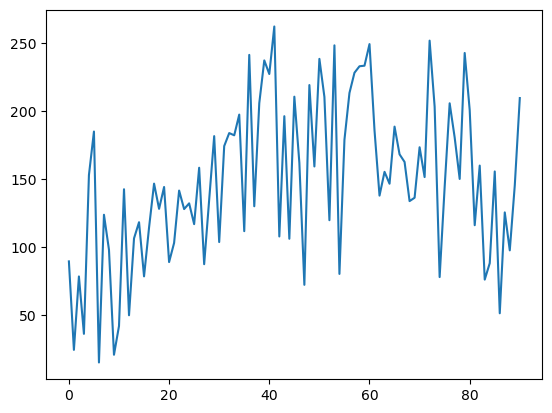

In [39]:
import matplotlib.pyplot as plt

plt.plot(filtered_compiled_input_output['intensity_from_neighborhood'].to_list()[0])
# plt.savefig("embryo2_testplot.png")

In [27]:
filtered_compiled_input_output['intensity_from_neighborhood'].to_list()[0]

array([ 89.39234545,  24.36781731,  78.32530909,  36.14945872,
       152.84063889, 184.82577876,  15.10376271, 123.66526496,
        97.94816667,  20.78254   ,  41.85600917, 142.41301818,
        49.79586239, 106.31805405, 118.19090385,  78.38838182,
       114.26722222, 146.53023636, 128.00475728, 144.06673   ,
        88.90313725, 102.97153448, 141.45492233, 127.83634286,
       132.05441176, 116.77845098, 158.21852632,  87.328     ,
       134.70441346, 181.45105882, 103.60930841, 174.14763107,
       183.6984087 , 182.05095455, 197.26328829, 111.60112613,
       241.1530566 , 129.90105556, 205.6532807 , 237.09934234,
       227.09110185, 262.03142857, 107.70491509, 196.09957547,
       106.0256422 , 210.43811504, 161.83088889,  72.17005102,
       218.98535644, 159.15325   , 238.22875   , 210.25555172,
       119.66420755, 248.16714019,  80.18707477, 178.79262727,
       213.17942857, 228.03302062, 232.79430435, 233.2119619 ,
       249.07964151, 185.72566116, 137.73933333, 155.20

In [18]:
filtered_compiled_input_output

,particle,frame,t_s,intensity_from_neighborhood,intensity_std_error_from_neighborhood,background_intensity_from_neighborhood
2,3,"[386, 387, 388, 390, 391, 392, 393, 394, 396, ...","[1488.6000003814697, 1492.3880004882812, 1496....","[89.39234545454546, 24.367817307692306, 78.325...","[37.20335218948968, 38.66980636463045, 35.9401...","[1.4990181818181818, 1.706682692307692, 1.6165..."
3,4,"[437, 439, 443, 450, 452, 453, 455, 456, 458, ...","[1681.2999992370605, 1688.5200004577637, 1704....","[67.63395283018868, 64.13552293577982, 76.3116...","[30.089570210283313, 31.221063652432793, 34.69...","[1.1643867924528304, 1.2540917431192662, 1.321..."
4,5,"[455, 456, 458, 464, 465, 466, 468, 470, 472, ...","[1748.7399997711182, 1752.5279998779297, 1760....","[15.925076923076924, 62.06902542372882, 72.615...","[40.54382936465543, 30.951190378793754, 37.726...","[1.4709615384615387, 1.1709915254237286, 1.199..."
5,6,"[394, 400, 406, 407, 411, 412, 417, 419, 420, ...","[1517.507999420166, 1540.5679988861084, 1563.2...","[49.29316216216216, 48.364036697247705, 67.269...","[38.83874893901341, 39.833900625647395, 37.626...","[1.5894594594594595, 1.5580275229357798, 1.446..."
6,7,"[410, 415, 422, 423, 428, 429, 440, 443, 444, ...","[1579.7799987792969, 1598.715000152588, 1625.2...","[74.04642857142858, 104.01784259259259, 91.576...","[35.165011998825634, 34.74314674414365, 32.101...","[1.4590102040816326, 1.2825648148148148, 1.251..."
...,...,...,...,...,...,...
319,336,"[14, 15, 16, 17, 18, 20, 21, 23, 24, 25, 26, 2...","[54.70000076293945, 58.148000717163086, 62.273...","[201.29567256637168, 250.3002857142857, 199.92...","[45.24402811296922, 40.99537183833396, 44.1500...","[2.205353982300885, 2.027071428571429, 2.17688..."
322,339,"[32, 36, 37, 39, 41, 44, 46, 48, 50, 52, 53, 5...","[123.15999984741211, 138.29300117492676, 142.0...","[89.43760550458715, 90.60536842105265, 108.497...","[39.535585293967394, 39.81093635061801, 40.689...","[1.8694678899082569, 1.902736842105263, 1.8187..."
329,346,"[14, 15, 16, 17, 18, 22, 23, 24, 25, 26, 27, 2...","[53.66800117492676, 57.45300102233887, 61.2399...","[153.96895098039218, 104.33604672897197, 121.8...","[42.39272409778919, 42.81652185871912, 42.3338...","[1.8932843137254902, 2.0470934579439253, 2.073..."
330,347,"[15, 16, 17, 18, 20, 21, 23, 24, 25, 26, 27, 2...","[58.82800102233887, 62.61300086975098, 66.7350...","[172.25173043478262, 118.36589189189189, 169.9...","[46.82097551562044, 45.96453956487815, 43.2277...","[2.2535478260869564, 2.388855855855856, 2.2005..."


In [1]:
%matplotlib notebook
import matplotlib
#matplotlib.use('TkAgg')
import matplotlib.pyplot as plt



curr_pos = 0


def key_event(e):
    global curr_pos

    if e.key == "right":
        curr_pos = curr_pos + 1
    elif e.key == "left":
        curr_pos = curr_pos - 1
    else:
        return

    curr_pos = curr_pos % len(filtered_compiled_input_output.index)

    t_s = filtered_compiled_input_output.loc[curr_pos, "t_s"]
    intensity_trace = filtered_compiled_input_output.loc[
        curr_pos, "intensity_from_neighborhood"
    ]
    intensity_err = filtered_compiled_input_output.loc[
        curr_pos, "intensity_std_error_from_neighborhood"
    ]

    ax_out.cla()
    ax_out.errorbar(
        t_s, intensity_trace, yerr=intensity_err, fmt=".", color="red", label="MS2"
    )

    ax_out.set_xlabel("time (s)")
    ax_out.set_ylabel("Spot intensity (AU)")
    title = "particle"
    ax_out.set_title(f"Particle {filtered_compiled_input_output.loc[curr_pos, title]}")
    ax_out.legend()

    # nuclear_t_s = filtered_compiled_input_output.loc[curr_pos, "nuclear_t_s"]
    # nuclear_trace = filtered_compiled_input_output.loc[
    #     curr_pos, "nuclear_intensity_mean"
    # ]
    # nuclear_err = filtered_compiled_input_output.loc[
    #     curr_pos, "nuclear_intensity_stdev"
    # ]

    # ax_in.cla()
    # ax_in.errorbar(
    #     nuclear_t_s, nuclear_trace, yerr=None, fmt=".", color="green", label="Bcd"
    # )
    #
    # ax_in.set_ylabel("Mean nuclear intensity (AU)")
    # ax_in.yaxis.set_label_position("right")

    fig.legend(loc="upper right", bbox_to_anchor=(1, 1), bbox_transform=ax.transAxes)

    fig.canvas.draw()


fig = plt.figure()
fig.canvas.mpl_connect("key_press_event", key_event)

ax_out = fig.add_subplot(111)

t_s = filtered_compiled_input_output.loc[curr_pos, "t_s"]
intensity_trace = filtered_compiled_input_output.loc[
    curr_pos, "intensity_from_neighborhood"
]
intensity_err = filtered_compiled_input_output.loc[
    curr_pos, "intensity_std_error_from_neighborhood"
]

ax_out.errorbar(
    t_s, intensity_trace, yerr=intensity_err, fmt=".", color="red", label="MS2"
)

ax_out.set_xlabel("time (s)")
ax_out.set_ylabel("Spot intensity (AU)")
title = "particle"
ax_out.set_title(f"Particle {filtered_compiled_input_output.loc[curr_pos, title]}")
ax_out.legend()

# ax_in = ax_out.twinx()
#
# nuclear_t_s = filtered_compiled_input_output.loc[curr_pos, "nuclear_t_s"]
# nuclear_trace = filtered_compiled_input_output.loc[curr_pos, "nuclear_intensity_mean"]
# nuclear_err = filtered_compiled_input_output.loc[curr_pos, "nuclear_intensity_stdev"]
#
# ax_in.errorbar(
#     nuclear_t_s, nuclear_trace, yerr=None, fmt=".", color="green", label="Bcd"
# )
#
# ax_in.set_ylabel("Mean nuclear intensity (AU)")


fig.legend(loc="upper right", bbox_to_anchor=(1, 1),)# bbox_transform=ax_in.transAxes)


plt.show()

RuntimeError: 'widgets is not a recognised GUI loop or backend name

In [29]:
t_s.shape

(86,)

In [30]:
intensity_trace.shape

(91,)

To-do:
1. Update docs for spot analysis zarr handling.
2. ~~Add zarr parallelization for nuclear label expansion and transfer.~~
3. ~~Add memory sink after making (non-reordered) spot labels so that memory can be cleared before next blocking operation, and use it as source for reordering step.~~
4. ~~Parallelize label transfer when using zarr mode.~~
5. ~~Add adaptive tracking parameter (possibly wrap `SubnetOversize` exception).~~
6. ~~Add 2spot handling - this might need fixing `filter_multiple_spots`.~~
7. ~~Add order of operations control on filtering vs tracking with nuclear labels.~~
8. Move quantification to block bootstrapping.
9. Move fits to GPU.

In [12]:
spot_tracking.spot_dataframe[
    (spot_tracking.spot_dataframe["frame"] == 165)
    & (spot_tracking.spot_dataframe["label"] == 1603)
]

,label,z,y,x,frame,t_s,t_frame,raw_spot,coordinates_start,covariance_matrix,...,offset,cost,norm_cost,intensity_from_fit,intensity_std_error_from_fit,intensity_from_neighborhood,intensity_std_error_from_neighborhood,background_intensity_from_neighborhood,nuclear_label,particle
409111,1603,4.392485,180.621567,202.849362,165,642.995001,169,"[[[2, 2, 2, 1, 0, 1, 0, 5, 2], [0, 3, 3, 1, 2,...","[2, 1, 176, 198]","[[0.00503045646760384, 5.169266410949674e-08, ...",...,1.89566,491.082047,0.005834,232.523291,21.099257,293.459655,51.197249,422.860345,213,213


In [13]:
spot_tracking.spot_dataframe[
    (spot_tracking.spot_dataframe["frame"] == 165)
    & (spot_tracking.spot_dataframe["label"] == 1966)
]

,label,z,y,x,frame,t_s,t_frame,raw_spot,coordinates_start,covariance_matrix,...,offset,cost,norm_cost,intensity_from_fit,intensity_std_error_from_fit,intensity_from_neighborhood,intensity_std_error_from_neighborhood,background_intensity_from_neighborhood,nuclear_label,particle
409238,1966,4.694795,171.837424,215.147267,165,643.335001,169,"[[[2, 1, 2, 2, 2, 3, 3, 3, 0], [3, 2, 3, 0, 2,...","[2, 2, 167, 210]","[[0.01798610059842412, 6.852430776666054e-05, ...",...,1.936636,420.751991,0.004622,35.931924,6.490842,137.289879,44.00495,449.341121,213,0
